# Liệu thói quen sinh hoạt có ảnh hưởng gì đến khả năng mắc bệnh trầm cảm không?

Tiến hành đọc dữ liệu để xem trong dữ liệu có những yếu tố thói quen sinh hoạt nào liên quan

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style("whitegrid")
df = pd.read_csv("data_final.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140608 entries, 0 to 140607
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140608 non-null  int64  
 1   Name                                   140608 non-null  object 
 2   Gender                                 140608 non-null  object 
 3   Age                                    140608 non-null  float64
 4   City                                   140608 non-null  object 
 5   Working Professional or Student        140608 non-null  object 
 6   Profession                             140608 non-null  object 
 7   Academic Pressure                      140608 non-null  float64
 8   Work Pressure                          140608 non-null  float64
 9   CGPA                                   140608 non-null  float64
 10  Study Satisfaction                     140608 non-null  

Các yếu tố được xem xét bao gồm:
- Thói quen ăn uống (Dietary Habits)
- Thời gian học tập/làm việc (Work/Study Hours)
- Thời lượng ngủ (Sleep Duration)

### Câu hỏi nhỏ
- Thói quen ăn uống có làm tăng nguy cơ trầm cảm không?
- Số giờ làm/học có liên quan đến trầm cảm không?
- Thời lượng ngủ ảnh hưởng thế nào đến trầm cảm?
- Sự kết hợp hai yếu tố sinh hoạt mang lại nguy cơ mắc bệnh Trầm cảm (Depression) lớn hơn đáng kể so với tác động độc lập không?
- Càng nhiều thói quen xấu thì nguy cơ trầm cảm có càng cao không?



## Câu 1: Thói quen ăn uống có làm tăng nguy cơ trầm cảm không?

Mục tiêu của phân tích này là kiểm tra xem **thói quen ăn uống (Dietary Habits)**
có liên quan đến **tình trạng trầm cảm (Depression)** hay không.

Nếu chế độ ăn không lành mạnh có tỷ lệ trầm cảm cao hơn,
điều đó cho thấy **thói quen ăn uống có thể là một yếu tố ảnh hưởng đến sức khỏe tinh thần**.

In [3]:
diet_rate = df.groupby('Dietary Habits')['Depression'].mean() * 100

diet_rate

,Depression
Dietary Habits,
Healthy,11.794035
Moderate,16.549572
Unhealthy,26.056658


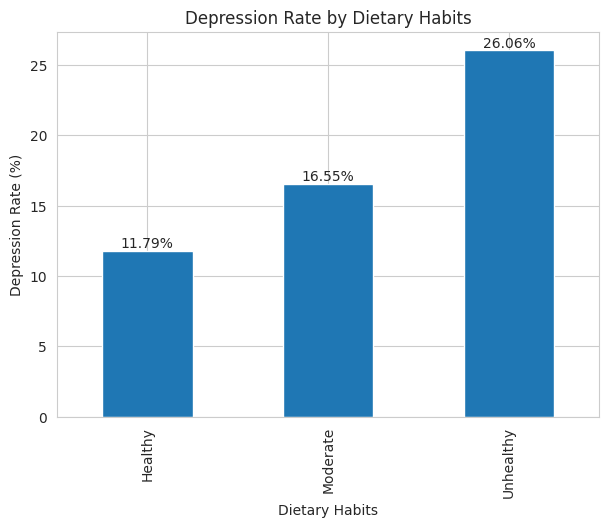

In [4]:
plt.figure(figsize=(7,5))

ax = diet_rate.plot(kind='bar')

# thêm số % trên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom')

plt.title("Depression Rate by Dietary Habits")
plt.xlabel("Dietary Habits")
plt.ylabel("Depression Rate (%)")
plt.savefig('h1.png')
plt.show()

### Nhận xét

Biểu đồ cho thấy tỷ lệ trầm cảm khác nhau giữa các nhóm thói quen ăn uống.

* Nhóm **Healthy** có tỷ lệ trầm cảm thấp nhất, khoảng **11.79%**.
* Nhóm **Moderate** có tỷ lệ trầm cảm cao hơn, khoảng **16.55%**.
* Nhóm **Unhealthy** có tỷ lệ trầm cảm cao nhất, khoảng **26.06%**.

Điều này cho thấy rằng những người có **chế độ ăn uống không lành mạnh có nguy cơ mắc trầm cảm cao hơn đáng kể** so với những người duy trì chế độ ăn uống lành mạnh.

Kết quả này gợi ý rằng **chế độ ăn uống có thể là một yếu tố quan trọng ảnh hưởng đến sức khỏe tinh thần**, và việc duy trì thói quen ăn uống lành mạnh có thể góp phần giảm nguy cơ trầm cảm.


## Câu 2: Số giờ làm/học có liên quan đến trầm cảm không?

Mục tiêu của phân tích này là kiểm tra xem **số giờ làm việc hoặc học tập mỗi ngày (Work/Study Hours)**
có liên quan đến **tình trạng trầm cảm (Depression)** hay không.

Nếu những người bị trầm cảm có xu hướng làm việc/học tập nhiều giờ hơn,
điều đó có thể cho thấy áp lực học tập hoặc công việc là một yếu tố góp phần
làm tăng nguy cơ trầm cảm.

/tmp/ipykernel_616/3661231901.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


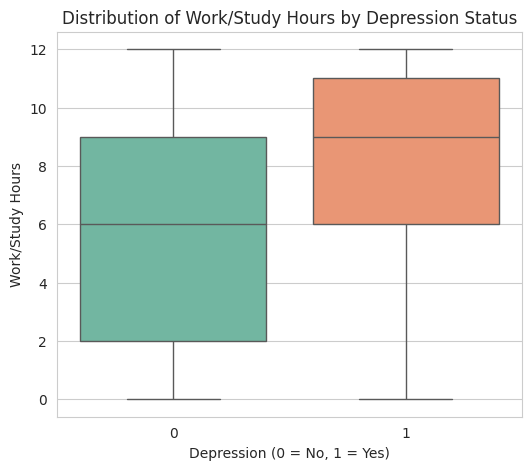

In [6]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x='Depression',
    y='Work/Study Hours',
    data=df,
    palette=['#66c2a5', '#fc8d62']  # màu cho 2 nhóm
)

plt.title("Distribution of Work/Study Hours by Depression Status")
plt.xlabel("Depression (0 = No, 1 = Yes)")
plt.ylabel("Work/Study Hours")

plt.show()

### Nhận xét

Biểu đồ boxplot cho thấy **phân bố số giờ làm/học của nhóm bị trầm cảm cao hơn so với nhóm không trầm cảm**. Cụ thể, **median (trung vị) số giờ làm/học của nhóm trầm cảm lớn hơn**, cho thấy những người thuộc nhóm này có xu hướng dành nhiều thời gian hơn cho công việc hoặc học tập.

Ngoài ra, phân bố của nhóm trầm cảm cũng **rộng hơn và xuất hiện nhiều giá trị cao**, cho thấy một số cá nhân trong nhóm này có số giờ làm/học rất lớn. Điều này gợi ý rằng **khối lượng công việc hoặc học tập cao có thể liên quan đến nguy cơ trầm cảm cao hơn**.


In [7]:
bins = [0, 5, 8, 12]
labels = ['Low', 'Medium', 'High']

df['Work/Study Hours'] = pd.cut(
    df['Work/Study Hours'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
df.to_csv("data_final.csv", index=False)

Cột Work/Study Hours được chia thành các khoảng giá trị (binning) để dễ phân tích và so sánh. Cụ thể:

0–5 giờ → Low
5–8 giờ → Medium
8–12 giờ → High

/tmp/ipykernel_616/721128692.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  work_dep = df.groupby('Work/Study Hours')['Depression'].mean()*100


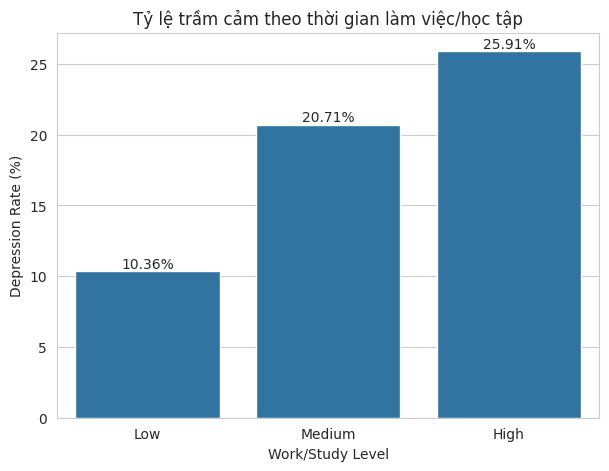

In [8]:
work_dep = df.groupby('Work/Study Hours')['Depression'].mean()*100
work_dep = work_dep.reset_index()
work_dep.columns = ['Work/Study Level', 'Depression Rate (%)']

# sắp xếp theo %
work_dep = work_dep.sort_values(by='Depression Rate (%)', ascending=True)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=work_dep,
    x='Work/Study Level',
    y='Depression Rate (%)'
)

# thêm % trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Tỷ lệ trầm cảm theo thời gian làm việc/học tập')
plt.xlabel('Work/Study Level')
plt.ylabel('Depression Rate (%)')
plt.savefig('h2.png')
plt.show()

### Nhận xét

Biểu đồ cho thấy tỷ lệ trầm cảm khác nhau giữa các mức thời gian học tập hoặc làm việc.

Nhóm **High** có tỷ lệ trầm cảm cao nhất, khoảng **25.91%**.  
Nhóm **Medium** có tỷ lệ trầm cảm khoảng **20.71%**, thấp hơn nhóm High nhưng vẫn cao hơn đáng kể so với nhóm Low.  
Trong khi đó, nhóm **Low** có tỷ lệ trầm cảm thấp nhất, chỉ khoảng **10.36%**.

Nhìn chung, tỷ lệ trầm cảm **tăng dần theo mức độ thời gian học tập hoặc làm việc**. Cụ thể, nhóm **High** có tỷ lệ trầm cảm cao hơn khoảng **15%** so với nhóm **Low**.

Kết quả này gợi ý rằng **thời gian học tập hoặc làm việc kéo dài có thể liên quan đến mức độ áp lực và căng thẳng cao hơn**, từ đó làm gia tăng nguy cơ trầm cảm.

## Câu 3: Thời lượng ngủ ảnh hưởng thế nào đến trầm cảm?

Mục tiêu của phân tích này là kiểm tra xem **thời lượng ngủ (Sleep Duration)**
có ảnh hưởng đến **tình trạng trầm cảm (Depression)** hay không?

Liệu những người ngủ quá ít hoặc không đủ giấc có thể dễ gặp
các vấn đề về tâm lý như căng thẳng hoặc trầm cảm hay không?

,Sleep_Level,Total_Sample,Depression_Rate (%)
0,1\nRất ít\n< 4 giờ,19,10.526316
1,2\nThấp\n4 - 6 giờ,70898,20.317922
2,3\nTrung bình\n6 - 8 giờ,12,16.666667
3,4\nLý tưởng\n7 - 9 giờ,36959,17.825158
4,5\nCao\n> 9 giờ,32720,13.872249


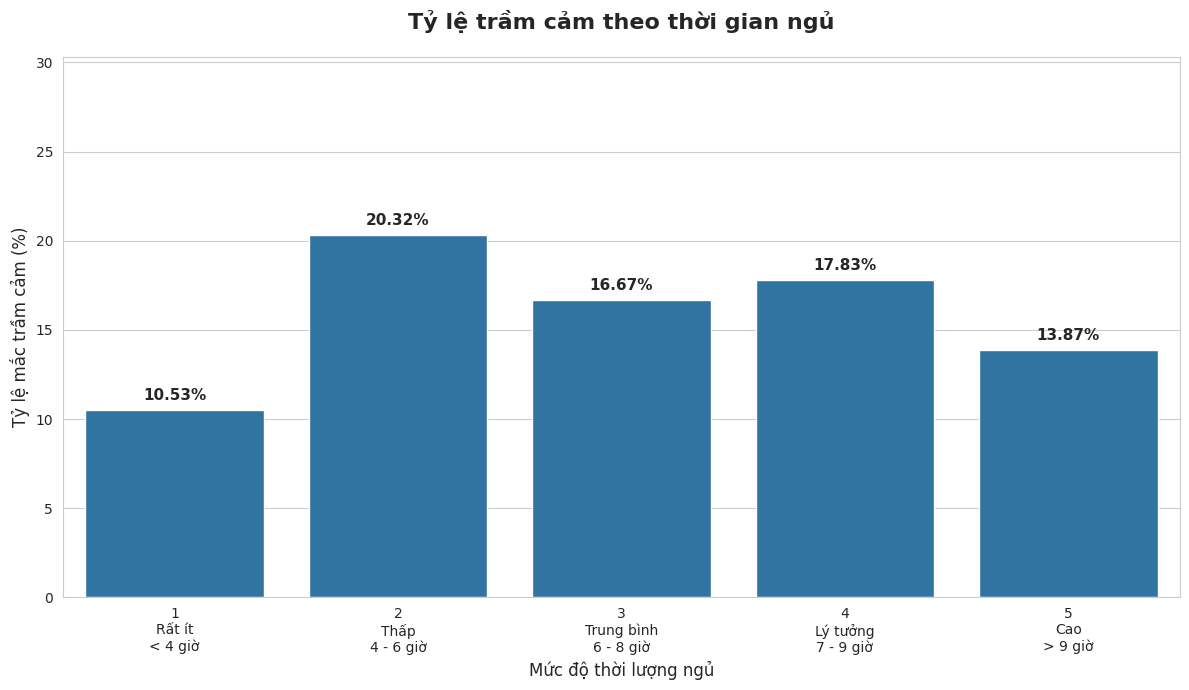

In [9]:
# 1. Tính toán tỷ lệ trầm cảm theo mức ngủ
sleep_analysis = df.groupby('Sleep Duration')['Depression'].agg(['count','mean']).reset_index()
sleep_analysis.columns = ['Sleep_Level', 'Total_Sample', 'Mean_Dep']
sleep_analysis['Depression_Rate (%)'] = sleep_analysis['Mean_Dep'] * 100


# 2. Mapping tên mức ngủ
sleep_labels = {
    1: "1\nRất ít\n< 4 giờ",
    2: "2\nThấp\n4 - 6 giờ",
    3: "3\nTrung bình\n6 - 8 giờ",
    4: "4\nLý tưởng\n7 - 9 giờ",
    5: "5\nCao\n> 9 giờ"
}

sleep_analysis['Sleep_Level'] = sleep_analysis['Sleep_Level'].map(sleep_labels)

# đảm bảo thứ tự đúng
order = list(sleep_labels.values())


# 3. Hiển thị bảng dữ liệu
display(sleep_analysis[['Sleep_Level','Total_Sample','Depression_Rate (%)']])


# 4. Vẽ biểu đồ
plt.figure(figsize=(12,7))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=sleep_analysis,
    x='Sleep_Level',
    y='Depression_Rate (%)',
    order=order,

)

# 5. Hiển thị % trên đầu cột
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                (p.get_x() + p.get_width()/2, height),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold',
                xytext=(0,5),
                textcoords='offset points')


# 6. Chỉnh layout
plt.title('Tỷ lệ trầm cảm theo thời gian ngủ', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mức độ thời lượng ngủ', fontsize=12)
plt.ylabel('Tỷ lệ mắc trầm cảm (%)', fontsize=12)

plt.xticks(rotation=0)
plt.ylim(0, sleep_analysis['Depression_Rate (%)'].max()+10)

plt.tight_layout()
plt.savefig('h3.png')
plt.show()

### Nhận xét

Biểu đồ cho thấy tỷ lệ trầm cảm khác nhau giữa các mức thời lượng ngủ.

* Nhóm ngủ **4–6 giờ** có tỷ lệ trầm cảm cao nhất, khoảng **20.3%**.
* Nhóm ngủ **6–8 giờ** và **7–9 giờ** có tỷ lệ trầm cảm thấp hơn, lần lượt khoảng **16.7%** và **17.8%**.
* Nhóm ngủ **trên 9 giờ** có tỷ lệ trầm cảm khoảng **13.9%**.
* Nhóm ngủ **rất ít (<4 giờ)** có tỷ lệ khoảng **10.5%**.

Nhìn chung, các mức ngủ **ngắn đến trung bình (đặc biệt 4–6 giờ)** có xu hướng liên quan đến tỷ lệ trầm cảm cao hơn. Điều này gợi ý rằng **thời lượng ngủ không phù hợp có thể liên quan đến sức khỏe tinh thần**, và việc duy trì giấc ngủ đủ và ổn định có thể giúp giảm nguy cơ trầm cảm.

## Câu 4: Sự kết hợp hai yếu tố sinh hoạt mang lại nguy cơ mắc bệnh Trầm cảm (Depression) lớn hơn đáng kể so với tác động độc lập không?

Mục tiêu của phân tích này là kiểm tra xem sự kết hợp giữa các cặp thói quen sinh hoạt bao gồm: thời lượng ngủ (Sleep Duration), số giờ làm việc/học tập (Work/Study Hours) và thói quen ăn uống (Dietary Habits) có tạo ra tác động cộng hưởng đến tình trạng trầm cảm (Depression).

Liệu những người làm việc/học tập với cường độ cao, kết hợp với việc thiếu ngủ và ăn uống không lành mạnh, thì nguy cơ rơi vào trầm cảm có tăng vọt (hiệu ứng khuếch đại) so với khi họ chỉ mắc phải một trong những thói quen xấu này hay không?

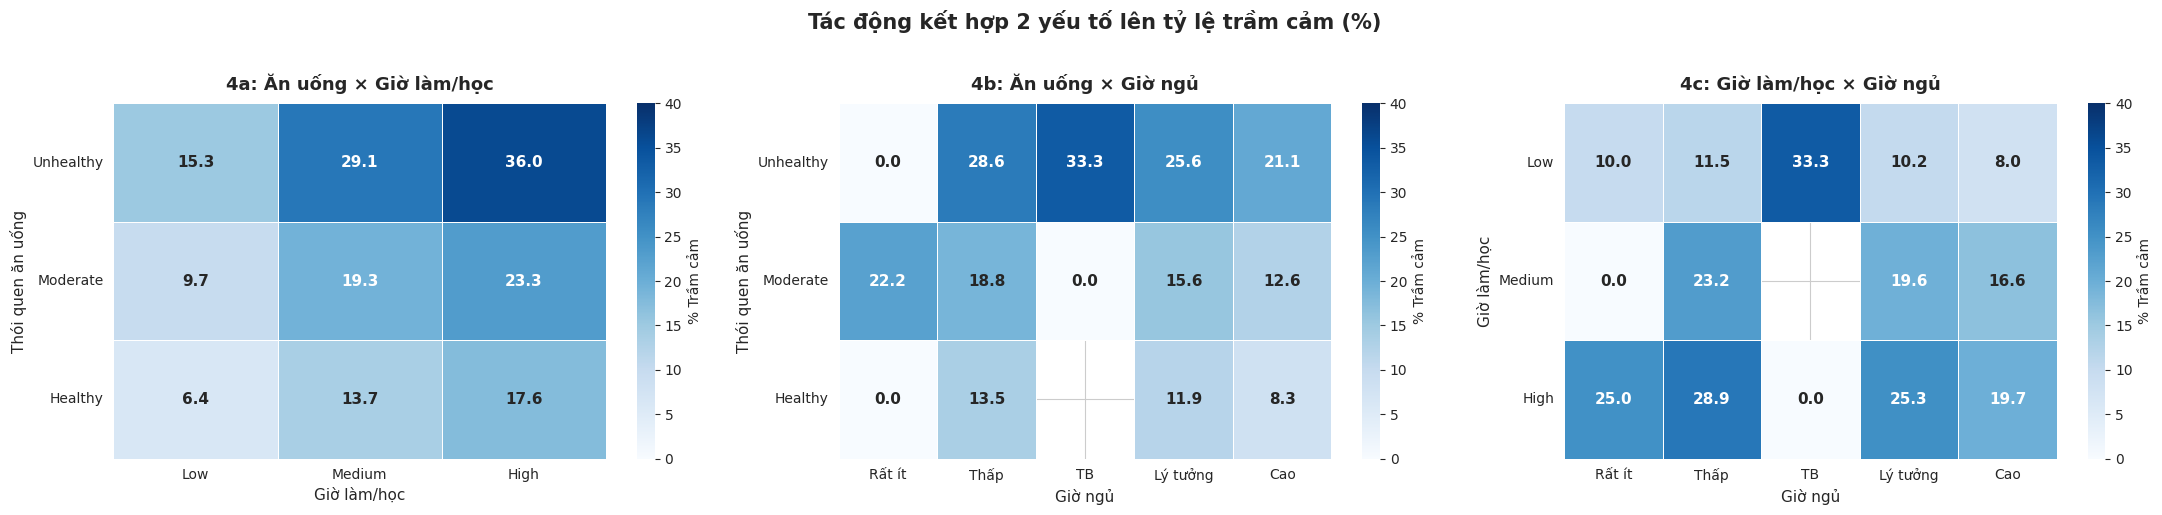

In [10]:
# 1. Khai báo từ điển
sleep_labels = {
    1: 'Rất ít',
    2: 'Thấp',
    3: 'TB',
    4: 'Lý tưởng',
    5: 'Cao'
}

# 2. Lấy dữ liệu
df['WSH_group'] = df['Work/Study Hours']
df['Sleep_label'] = df['Sleep Duration'].map(sleep_labels)

# 3. Định nghĩa thứ tự hiển thị
diet_order  = ['Unhealthy', 'Moderate', 'Healthy']
wsh_order   = ['Low', 'Medium', 'High']
sleep_order = list(sleep_labels.values())

# 4. Gom nhóm dữ liệu và tính tỷ lệ người mắc bệnh Trầm cảm (% Depression)
pivot_4a = (df.groupby(['Dietary Habits', 'WSH_group'], observed=True)['Depression']
              .mean().unstack()
              .reindex(index=diet_order, columns=wsh_order) * 100)

pivot_4b = (df.groupby(['Dietary Habits', 'Sleep_label'])['Depression']
              .mean().unstack()
              .reindex(index=diet_order, columns=sleep_order) * 100)

pivot_4c = (df.groupby(['WSH_group', 'Sleep_label'], observed=True)['Depression']
              .mean().unstack()
              .reindex(index=wsh_order, columns=sleep_order) * 100)

# 5. Vẽ biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Tác động kết hợp 2 yếu tố lên tỷ lệ trầm cảm (%)',
             fontsize=15, fontweight='bold', y=1.02)

vmin, vmax = 0, 40

def draw_hmap(ax, data, title, xlabel, ylabel):
    sns.heatmap(data, annot=True, fmt='.1f', cmap='Blues',
                vmin=vmin, vmax=vmax, linewidths=0.5, linecolor='white',
                ax=ax, annot_kws={'size': 11, 'weight': 'bold'},
                cbar_kws={'label': '% Trầm cảm'})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

draw_hmap(axes[0], pivot_4a, '4a: Ăn uống × Giờ làm/học', 'Giờ làm/học', 'Thói quen ăn uống')
draw_hmap(axes[1], pivot_4b, '4b: Ăn uống × Giờ ngủ', 'Giờ ngủ', 'Thói quen ăn uống')
draw_hmap(axes[2], pivot_4c, '4c: Giờ làm/học × Giờ ngủ', 'Giờ ngủ', 'Giờ làm/học')

plt.tight_layout()
plt.show()

### Nhận xét:
Các biểu đồ heatmap cho thấy tỷ lệ trầm cảm luôn đạt mức cao nhất khi các thói quen sinh hoạt tiêu cực xuất hiện cùng lúc:
* **Biểu đồ 4a (Ăn uống × Giờ làm/học):**  Nhóm có chế độ ăn kém (Unhealthy) và cường độ làm việc cao (High) có tỷ lệ trầm cảm cực kỳ cao, lên tới **36.0%**. Ngược lại, nhóm có lối sống lành mạnh nhất (ăn Healthy, làm việc Low) chỉ ở mức **6.4%**.
* **Biểu đồ 4b (Ăn uống × Giờ ngủ):** Sự kết hợp giữa chế độ ăn Unhealthy và thời lượng ngủ Thấp/TB đẩy rủi ro trầm cảm lên mức **28.6% – 33.3%**. Trong khi đó, người ăn Healthy và ngủ Cao chỉ ghi nhận tỷ lệ **8.3%**.
* **Biểu đồ 4c (Giờ làm/học × Giờ ngủ):** Nhóm người vắt kiệt sức với cường độ làm việc High nhưng ngủ Thấp có tỷ lệ trầm cảm là **28.9%**, cao gần gấp 3 lần so với những người làm việc cường độ Low và ngủ Lý tưởng (chỉ **10.2%**). Ngoài ra, ở nhóm làm/học thấp và ngủ Trung bình đạt đến con số **33,33%** là do tỉ lệ mẫu của nhóm này nhỏ (6 người) và có số người mắc trầm cảm là 2 dẫn đến nhiễu dữ liệu.

Kết luận: Sự kết hợp giữa hai yếu tố sinh hoạt xấu mang lại rủi ro mắc bệnh Trầm cảm lớn hơn đáng kể so với tổng các tác động độc lập. Các thói quen này không hoạt động riêng lẻ, mà chúng tương tác và làm trầm trọng thêm hậu quả của nhau đẩy người bệnh vào nguy cơ suy sụp tinh thần với tỷ lệ cao.

## Câu 5: Càng nhiều thói quen xấu thì nguy cơ trầm cảm có càng cao không?

Mục tiêu của phân tích này là kiểm tra xem **số lượng thói quen sinh hoạt không lành mạnh (Bad Habits)**
có ảnh hưởng đến **tình trạng trầm cảm (Depression)** hay không.

Các thói quen xấu được xem xét bao gồm những yếu tố như **thời gian ngủ không phù hợp, chế độ ăn uống không lành mạnh và thời gian học tập/làm việc quá nhiều**.
Những yếu tố này có thể làm gia tăng áp lực và ảnh hưởng tiêu cực đến sức khỏe tinh thần.

Phân tích này nhằm trả lời câu hỏi: **Liệu khi số lượng thói quen xấu tăng lên, nguy cơ mắc trầm cảm có tăng theo hay không?**

,Number of Bad Habits,Total Sample,Depression Rate (%)
0,0,30190,9.324280
1,1,61532,15.034454
2,2,39948,24.952438
3,3,8938,39.181025


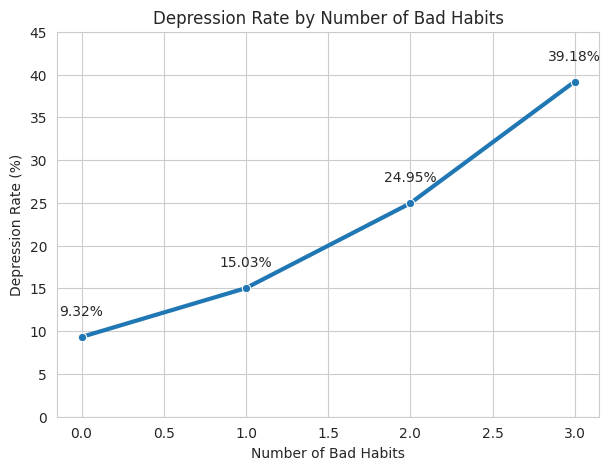

In [11]:
# 1. Tạo các biến thói quen xấu
df['bad_sleep'] = (df['Sleep Duration'] <= 2).astype(int)
df['bad_work'] = (df['Work/Study Hours'] == 'High').astype(int)
df['bad_diet'] = (df['Dietary Habits'] == 'Unhealthy').astype(int)

# 2. Tổng số thói quen xấu
df['bad_habits_count'] = (
    df['bad_sleep'] +
    df['bad_work'] +
    df['bad_diet']
)

# 3. Phân tích dữ liệu
habit_analysis = df.groupby('bad_habits_count')['Depression'].agg(['count','mean']).reset_index()
habit_analysis.columns = ['Number of Bad Habits','Total Sample','Mean']

habit_analysis['Depression Rate (%)'] = habit_analysis['Mean'] * 100

# hiển thị bảng số liệu
display(habit_analysis[['Number of Bad Habits','Total Sample','Depression Rate (%)']])

# 4. Vẽ biểu đồ
plt.figure(figsize=(7,5))

ax = sns.lineplot(
    data=habit_analysis,
    x='Number of Bad Habits',
    y='Depression Rate (%)',
    marker='o',
    linewidth=3
)

# thêm % trên từng điểm
for x, y in zip(habit_analysis['Number of Bad Habits'],
                habit_analysis['Depression Rate (%)']):
    plt.text(x, y + 2.5, f'{y:.2f}%', ha='center')

plt.title('Depression Rate by Number of Bad Habits')
plt.xlabel('Number of Bad Habits')
plt.ylabel('Depression Rate (%)')
plt.ylim(0,45)
plt.savefig('h5.png')
plt.show()

### Nhận xét

Biểu đồ cho thấy tỷ lệ trầm cảm tăng rõ rệt khi số lượng thói quen xấu tăng lên.

Những người **không có thói quen xấu** có tỷ lệ trầm cảm khoảng **9.32%**. Khi có **1 thói quen xấu**, tỷ lệ này tăng lên **15.03%**.

Đối với những người có **2 thói quen xấu**, tỷ lệ trầm cảm tăng đáng kể lên **24.95%**. Đặc biệt, ở nhóm có **3 thói quen xấu**, tỷ lệ trầm cảm đạt mức cao nhất khoảng **39.18%**, cao hơn hơn **4 lần** so với nhóm không có thói quen xấu.

Kết quả này cho thấy số lượng thói quen sinh hoạt không lành mạnh có mối liên hệ mạnh với nguy cơ trầm cảm. Khi nhiều thói quen xấu xuất hiện cùng lúc, nguy cơ trầm cảm có xu hướng tăng mạnh, cho thấy **hiệu ứng tích lũy (cumulative effect)** của các yếu tố lối sống đối với sức khỏe tinh thần.

## Kết luận tổng thể:
Kết quả phân tích cho thấy **thói quen sinh hoạt có mối liên hệ rõ ràng với nguy cơ trầm cảm.** Những người có **chế độ ăn uống không lành mạnh, ngủ ít và làm việc/học tập nhiều giờ thường có tỷ lệ trầm cảm cao hơn**. Ngoài ra, khi **nhiều thói quen xấu** xuất hiện cùng lúc, **nguy cơ trầm cảm tăng lên đáng kể**. Điều này cho thấy **càng nhiều thói quen sinh hoạt không lành mạnh thì khả năng mắc trầm cảm càng cao**.